In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista6/Zad1

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from itertools import product
import warnings

In [27]:
CONFIG = {
    'rys1': {
        'filename': 'rys1.png',
        'K_POINTS': 200,  # Szacowana liczba prawdziwych punktów danych
        'KMEANS_K': 4,    
        'DBSCAN_EPS': 30, 
        'DBSCAN_MIN_SAMPLES': 5, 
        'H_CLUSTERS': 3   
    },
    'rys2': {
        'filename': 'rys2.png',
        'K_POINTS': 200,
        'KMEANS_K': 4,
        'DBSCAN_EPS': 25, 
        'DBSCAN_MIN_SAMPLES': 5,
        'H_CLUSTERS': 5
    },
    'rys3': {
        'filename': 'rys3.png',
        'K_POINTS': 300,
        'KMEANS_K': 4,
        'DBSCAN_EPS': 30, 
        'DBSCAN_MIN_SAMPLES': 5,
        'H_CLUSTERS': 5
    }
}

In [28]:
def extract_data_from_image(filename, k_points):
    img = Image.open(filename).convert('RGB')
    img_array = np.array(img)
    
    is_white = (img_array[:, :, 0] == 255) & \
               (img_array[:, :, 1] == 255) & \
               (img_array[:, :, 2] == 255)
    
    non_white_pixels = np.argwhere(~is_white)
    
    k_points = min(k_points, len(non_white_pixels))

    kmeans_pixels = KMeans(n_clusters=k_points, random_state=2137, n_init=10)
    kmeans_pixels.fit(non_white_pixels)
    
    data_points = kmeans_pixels.cluster_centers_
    
    return data_points

In [ ]:
def plot_clustering_results(data, labels, title, data_name, ax):
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap('viridis', len(unique_labels))
    for i, label in enumerate(unique_labels):
        if label == -1: # DBSCAN oznacza -1 jako szum (kolor czarny)
            color = 'black'
            label_name = 'Szum (DBSCAN)'
        else:
            color = colors(i)
            label_name = f'Klaster {label}'
            
        mask = (labels == label)
        ax.scatter(data[mask, 0], data[mask, 1], 
                   s=10, 
                   alpha=0.7, 
                   color=color, 
                   label=label_name)

    ax.set_title(f'{title}\nZbiór: {data_name}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

/tmp/ipykernel_3495/980012996.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))
/tmp/ipykernel_3495/980012996.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))
/tmp/ipykernel_3495/980012996.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))
/tmp/ipykernel_3495/980012996.py:3: MatplotlibDeprec

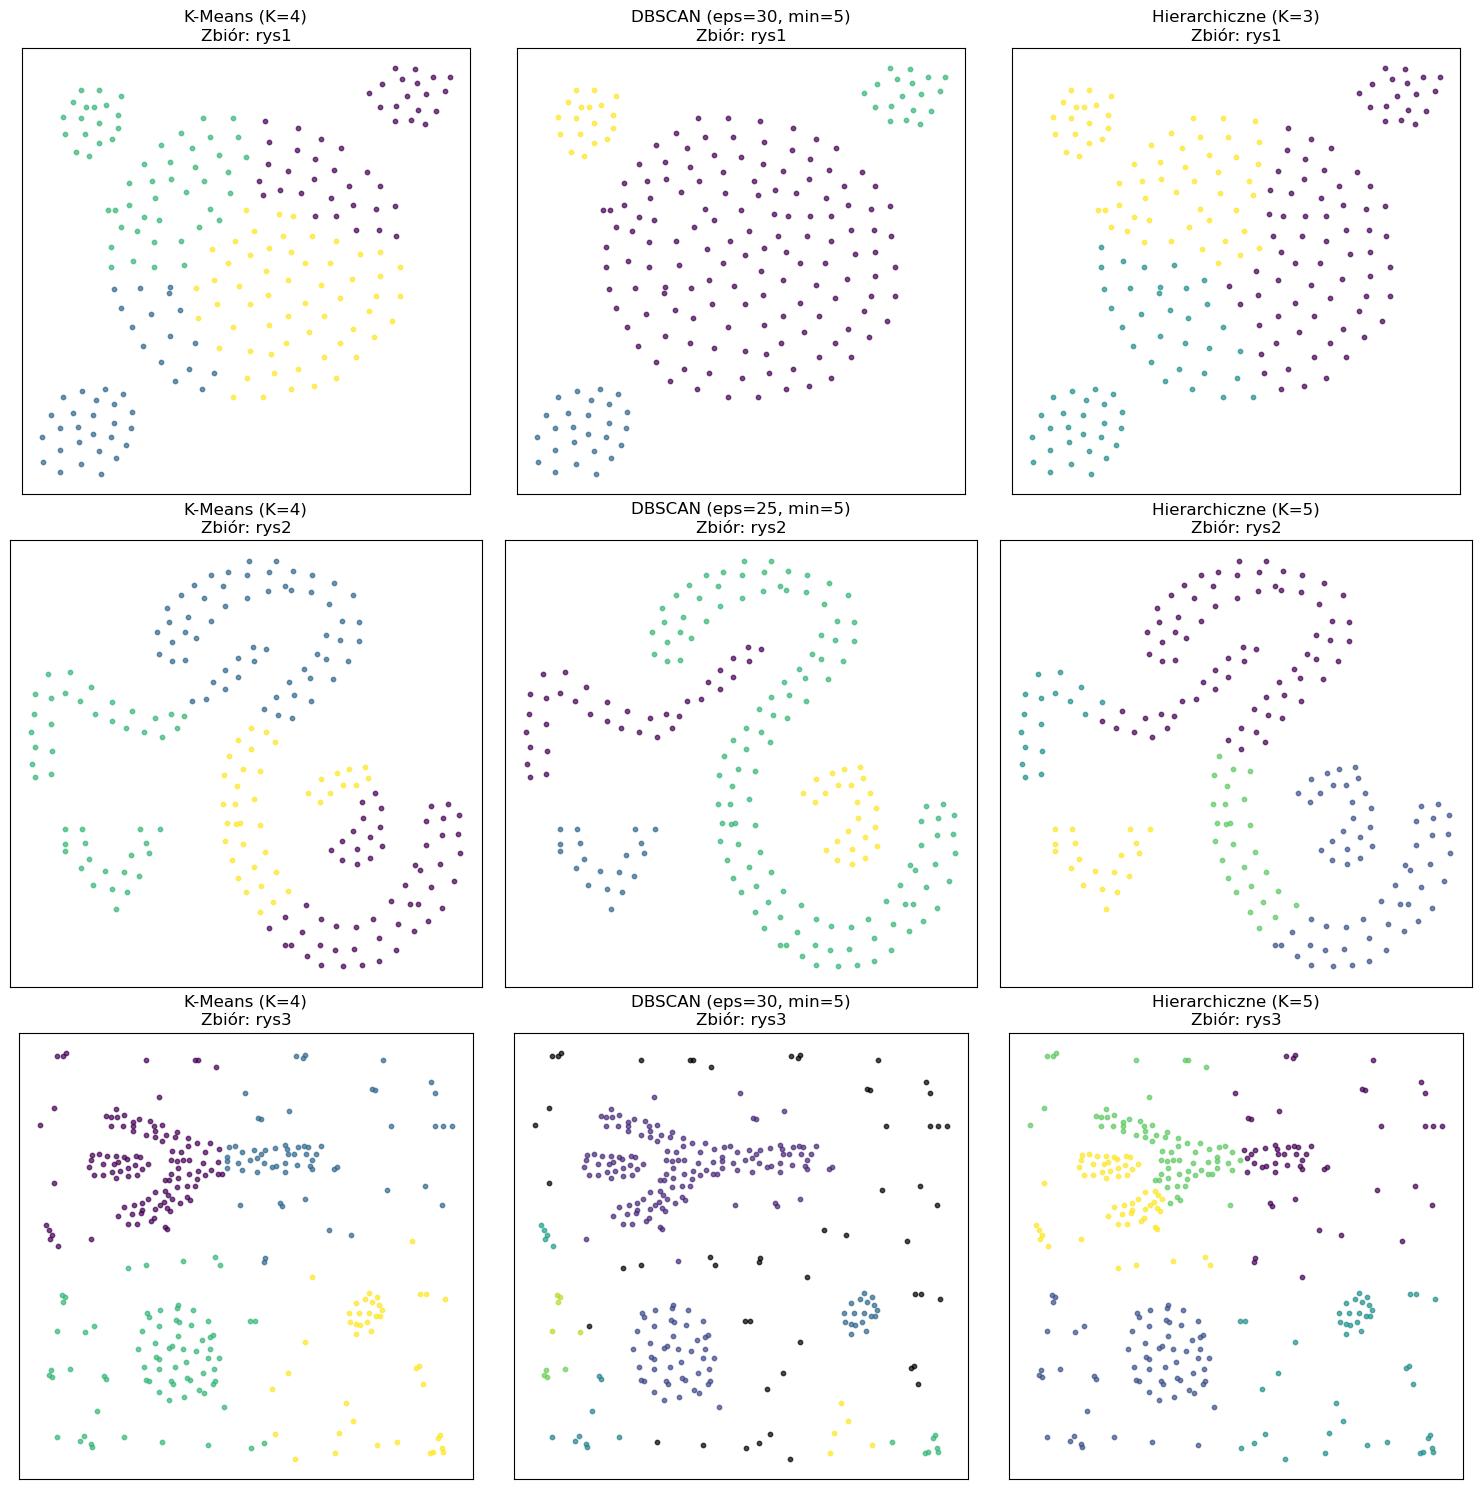

In [30]:
extracted_data = {}
for name, params in CONFIG.items():
    data = extract_data_from_image(params['filename'], params['K_POINTS'])
    if data is not None:
        extracted_data[name] = data

# Przygotowanie figure (9 podwykresów: 3 zbiory x 3 algorytmy)
fig, axes = plt.subplots(len(extracted_data), 3, figsize=(15, 5 * len(extracted_data)))

for row_idx, (data_name, data) in enumerate(extracted_data.items()):
    
    params = CONFIG[data_name]
    
    # A. K-Means 
    kmeans = KMeans(n_clusters=params['KMEANS_K'], random_state=2137, n_init=10)
    labels_kmeans = kmeans.fit_predict(data)
    plot_clustering_results(data, labels_kmeans, 
                            f'K-Means (K={params["KMEANS_K"]})', data_name, axes[row_idx, 0])
    
    # B. DBSCAN 
    dbscan = DBSCAN(eps=params['DBSCAN_EPS'], min_samples=params['DBSCAN_MIN_SAMPLES'])
    labels_dbscan = dbscan.fit_predict(data)
    plot_clustering_results(data, labels_dbscan, 
                            f'DBSCAN (eps={params["DBSCAN_EPS"]}, min={params["DBSCAN_MIN_SAMPLES"]})', 
                            data_name, axes[row_idx, 1])

    # C. Grupowanie Hierarchiczne 
    agg_clust = AgglomerativeClustering(n_clusters=params['H_CLUSTERS'])
    labels_agg = agg_clust.fit_predict(data)
    plot_clustering_results(data, labels_agg, 
                            f'Hierarchiczne (K={params["H_CLUSTERS"]})', data_name, axes[row_idx, 2])

plt.tight_layout()
plt.show()

DB SCAN świetnie sobie radzi z tymi danymi

Tak jak omawialiśmy na wykładzie Kmeans są do nich bezurzutyczne bo nie da ich się podzielić dobrze racjonalną liczbą prostych

Hierarhiczne słabo sobie radzą dlatego, że to co my intereptujemy jako klastry oczami są dosyć mocno rzoeciągnięte i niektóre punkty mają pomiedzy sobą dosyć spore odległości